# Testing stuff
Here I am testing python modules and data processing techniques, to get familiar with tools.

In [9]:
import torch

torch.manual_seed(69)

print("Testing concatenations....")
a = torch.randn(5,3)
b = torch.randn(5,3)
print("A", a)
print("B", b)
print("Concatenated:", torch.cat((a, b), dim=1))

Testing concatenations....
A tensor([[-0.5259, -2.6043, -0.6448],
        [ 1.4356, -0.5796, -0.7254],
        [ 1.6112, -0.0703,  0.4757],
        [-0.3330, -0.0810, -1.2897],
        [-1.1969,  0.6707, -1.2555]])
B tensor([[-1.1164,  1.2523, -1.5541],
        [-1.4058, -0.3329, -0.2117],
        [-0.4752,  0.0606,  1.9731],
        [ 0.1399,  0.1372, -2.0599],
        [ 1.1843,  0.4051, -0.0157]])
Concatenated: tensor([[-0.5259, -2.6043, -0.6448, -1.1164,  1.2523, -1.5541],
        [ 1.4356, -0.5796, -0.7254, -1.4058, -0.3329, -0.2117],
        [ 1.6112, -0.0703,  0.4757, -0.4752,  0.0606,  1.9731],
        [-0.3330, -0.0810, -1.2897,  0.1399,  0.1372, -2.0599],
        [-1.1969,  0.6707, -1.2555,  1.1843,  0.4051, -0.0157]])


## Exploring candidate datasets for training

### IOTID20
Apparently, this dataset is imbalanced, gives mainly focus on mirai attacks. Benign traffic is a minority.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625783 entries, 0 to 625782
Data columns (total 86 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow_ID            625783 non-null  object 
 1   Src_IP             625783 non-null  object 
 2   Src_Port           625783 non-null  int64  
 3   Dst_IP             625783 non-null  object 
 4   Dst_Port           625783 non-null  int64  
 5   Protocol           625783 non-null  int64  
 6   Timestamp          625783 non-null  object 
 7   Flow_Duration      625783 non-null  int64  
 8   Tot_Fwd_Pkts       625783 non-null  int64  
 9   Tot_Bwd_Pkts       625783 non-null  int64  
 10  TotLen_Fwd_Pkts    625783 non-null  float64
 11  TotLen_Bwd_Pkts    625783 non-null  float64
 12  Fwd_Pkt_Len_Max    625783 non-null  float64
 13  Fwd_Pkt_Len_Min    625783 non-null  float64
 14  Fwd_Pkt_Len_Mean   625783 non-null  float64
 15  Fwd_Pkt_Len_Std    625783 non-null  float64
 16  Bw

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Cat,Sub_Cat
0,192.168.0.13-192.168.0.16-10000-10101-17,192.168.0.13,10000,192.168.0.16,10101,17,25/07/2019 03:25:53 AM,75,1,1,...,0.0,0.0,0.0,75.0,0.000000,75.0,75.0,Anomaly,Mirai,Mirai-Ackflooding
1,192.168.0.13-222.160.179.132-554-2179-6,222.160.179.132,2179,192.168.0.13,554,6,26/05/2019 10:11:06 PM,5310,1,2,...,0.0,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,Anomaly,DoS,DoS-Synflooding
2,192.168.0.13-192.168.0.16-9020-52727-6,192.168.0.16,52727,192.168.0.13,9020,6,11/07/2019 01:24:48 AM,141,0,3,...,0.0,0.0,0.0,70.5,0.707107,71.0,70.0,Anomaly,Scan,Scan Port OS
3,192.168.0.13-192.168.0.16-9020-52964-6,192.168.0.16,52964,192.168.0.13,9020,6,04/09/2019 03:58:17 AM,151,0,2,...,0.0,0.0,0.0,151.0,0.000000,151.0,151.0,Anomaly,Mirai,Mirai-Hostbruteforceg
4,192.168.0.1-239.255.255.250-36763-1900-17,192.168.0.1,36763,239.255.255.250,1900,17,10/09/2019 01:41:18 AM,153,2,1,...,0.0,0.0,0.0,76.5,0.707107,77.0,76.0,Anomaly,Mirai,Mirai-Hostbruteforceg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625778,192.168.0.24-210.89.164.90-56112-8043-17,192.168.0.24,56112,210.89.164.90,8043,17,25/07/2019 03:25:00 AM,277,1,1,...,0.0,0.0,0.0,277.0,0.000000,277.0,277.0,Anomaly,Mirai,Mirai-UDP Flooding
625779,192.168.0.13-222.131.171.244-554-4570-6,222.131.171.244,4570,192.168.0.13,554,6,26/05/2019 10:06:51 PM,1658,0,2,...,0.0,0.0,0.0,1658.0,0.000000,1658.0,1658.0,Anomaly,DoS,DoS-Synflooding
625780,192.168.0.13-192.168.0.16-9020-52739-6,192.168.0.16,52739,192.168.0.13,9020,6,11/07/2019 01:29:09 AM,77,1,1,...,0.0,0.0,0.0,77.0,0.000000,77.0,77.0,Anomaly,Scan,Scan Port OS
625781,192.168.0.13-192.168.0.16-9020-49784-6,192.168.0.13,9020,192.168.0.16,49784,6,20/05/2019 05:00:29 AM,240,2,1,...,0.0,0.0,0.0,120.0,7.071068,125.0,115.0,Normal,Normal,Normal


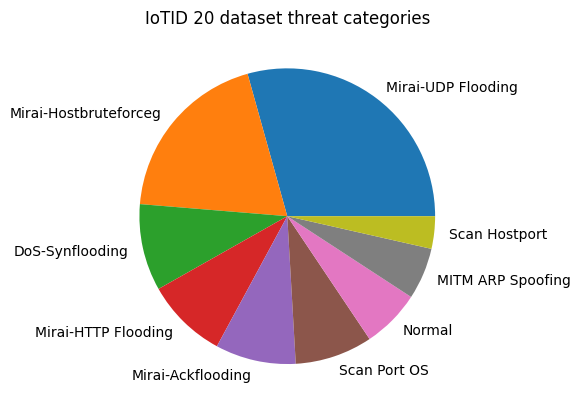

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/iotid20/iotid20.csv")
categories = df["Sub_Cat"].value_counts()

def percent_formatter(x):
    return "{}\n({:.1f})%".format(int(categories.sum()*x/100) ,x)

plt.pie(categories.values, labels=categories.index)
plt.title("IoTID 20 dataset threat categories")
df.info()
df

### IoT-23

This is a large dataset. Split up to multiple csvs according to attack vector. A large portion of data are benign traffic. Contains the following attack types:
- Command and Control
- DDoS
- Malicious file downloads
- Mirai
- Okiru
- Port scan
- Heartbeat
- Torii

In [11]:
import pandas as pd

del df

df = pd.read_csv("../datasets/IoT-23/attacks/DDoS[1].csv")
df.shape[1]
df

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,Fwd_Pkt_Len_Mean,Fwd_Pkt_Len_Std,Bwd_Pkt_Len_Max,Bwd_Pkt_Len_Min,Bwd_Pkt_Len_Mean,Bwd_Pkt_Len_Std,Flow_Byts/s,Flow_Pkts/s,Flow_IAT_Mean,Flow_IAT_Std,Flow_IAT_Max,Flow_IAT_Min,Fwd_IAT_Tot,Fwd_IAT_Mean,Bwd_IAT_Mean,Fwd_IAT_Max,Fwd_IAT_Min,Bwd_IAT_Tot,Bwd_IAT_Mean.1,Bwd_IAT_Std,Bwd_IAT_Max,Bwd_IAT_Min,Fwd_PSH_Flags,Bwd_PSH_Flags,Fwd_URG_Flags,Bwd_URG_Flags,...,Pkt_Len_Max,Pkt_Len_Mean,Pkt_Len_Std,Pkt_Len_Var,FIN_Flag_Cnt,SYN_Flag_Cnt,RST_Flag_Cnt,PSH_Flag_Cnt,ACK_Flag_Cnt,URG_Flag_Cnt,CWE_Flag_Count,ECE_Flag_Cnt,Down/Up_Ratio,Pkt_Size_Avg,Fwd_Seg_Size_Avg,Bwd_Seg_Size_Avg,Fwd_Byts/b_Avg,Fwd_Pkts/b_Avg,Fwd_Blk_Rate_Avg,Bwd_Byts/b_Avg,Bwd_Pkts/b_Avg,Bwd_Blk_Rate_Avg,Subflow_Fwd_Pkts,Subflow_Fwd_Byts,Subflow_Bwd_Pkts,Subflow_Bwd_Byts,Init_Fwd_Win_Byts,Init_Bwd_Win_Byts,Fwd_Act_Data_Pkts,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Sub_Cat
0,192.168.100.108-64.237.233.111-2074-80-17,192.168.100.108,2074,64.237.233.111,80,17,20/07/2018 05:44:44 PM,1678539,2,0,1024.0,0.0,512.0,512.0,512.0,0.0,0.0,0.0,0.0,0.0,610.054339,1.191512e+00,1678539.0,0.000,1678539.0,1678539.0,1678539.0,1678539.0,0.000,1678539.0,1678539.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,512.0,512.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,768.000000,512.0,0.0,0,0,0,0,0,0,1,512,0,0,0,0,1,8,0,0,0,0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,Anomaly,DDoS
1,192.168.100.108-64.237.233.111-8356-80-17,192.168.100.108,8356,64.237.233.111,80,17,20/07/2018 05:44:11 PM,34506819,2,0,1024.0,0.0,512.0,512.0,512.0,0.0,0.0,0.0,0.0,0.0,29.675294,5.795956e-02,34506819.0,0.000,34506819.0,34506819.0,34506819.0,34506819.0,0.000,34506819.0,34506819.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,512.0,512.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,768.000000,512.0,0.0,0,0,0,0,0,0,1,512,0,0,0,0,1,8,0,0,0,0,3.450682e+07,0.0,3.450682e+07,3.450682e+07,Anomaly,DDoS
2,192.168.100.108-64.237.233.111-49635-80-17,192.168.100.108,49635,64.237.233.111,80,17,20/07/2018 05:44:23 PM,3757355,2,0,1024.0,0.0,512.0,512.0,512.0,0.0,0.0,0.0,0.0,0.0,272.532140,5.322893e-01,3757355.0,0.000,3757355.0,3757355.0,3757355.0,3757355.0,0.000,3757355.0,3757355.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,512.0,512.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,768.000000,512.0,0.0,0,0,0,0,0,0,1,512,0,0,0,0,1,8,0,0,0,0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,Anomaly,DDoS
3,192.168.100.108-64.237.233.111-41458-80-17,192.168.100.108,41458,64.237.233.111,80,17,20/07/2018 05:44:24 PM,26676285,2,0,1024.0,0.0,512.0,512.0,512.0,0.0,0.0,0.0,0.0,0.0,38.386155,7.497296e-02,26676285.0,0.000,26676285.0,26676285.0,26676285.0,26676285.0,0.000,26676285.0,26676285.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,512.0,512.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,768.000000,512.0,0.0,0,0,0,0,0,0,1,512,0,0,0,0,1,8,0,0,0,0,2.667628e+07,0.0,2.667628e+07,2.667628e+07,Anomaly,DDoS
4,192.168.100.108-64.237.233.111-41910-80-17,192.168.100.108,41910,64.237.233.111,80,17,20/07/2018 05:44:23 PM,9054086,3,0,1536.0,0.0,512.0,512.0,512.0,0.0,0.0,0.0,0.0,0.0,169.647163,3.313421e-01,4527043.0,5536493.362,8441935.0,612151.0,9054086.0,4527043.0,5536493.362,8441935.0,612151.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...,512.0,512.0,0.0,0.0,0,0,0,0,0,0,0,0,0.0,682.666667,512.0,0.0,0,0,0,0,0,0,1,512,0,0,0,0,2,8,0,0,0,0,1.532120e+15,0.0,1.532120e+15,1.532120e+15,Anomaly,DDoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5393741,192.168.100.111-41.203.92.164-18344-52869-6,192.168.100.111,18344,41.203.92.164,52869,6,06/09/2018 03:05:48 PM,2,2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000e+06,2.0,0.000,2.0,2.0,2.0,2.0,0.000,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,...